## Google Drive Bağlantısı ve Gerekli Paketlerin Kurulması

In [ ]:
# Google Drive'a bağlan
from google.colab import drive
drive.mount('/content/drive')



In [ ]:
!pip install colorama
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib
!pip install pandas

## Temel Ayarlar ve Path Tanımları

In [ ]:
import os

# Ana dizinleri ayarla
BASE_PATH = '/content/drive/MyDrive/Human Bone Fractures Multi-modal Image Dataset (HBFMID)'
MODEL_SAVE_DIR = os.path.join(BASE_PATH, 'models_trained')
PLOT_SAVE_DIR = os.path.join(BASE_PATH, 'plots_generated')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(PLOT_SAVE_DIR, "BodyParts"), exist_ok=True)

# Sınıf etiketleri
BODY_PART_CLASS_MAPPING = {
    0: 'Elbow',
    1: 'Hand',
    2: 'Shoulder',
    3: 'Femur',
    4: 'Fractured',
    5: 'Intact',
    6: 'Another',
    7: 'FractureType1',
    8: 'FractureType2',
    9: 'FractureType3'
}


## YOLO'dan DataFrame Oluşturma ve Veri Setini Hazırlama

In [ ]:
import pandas as pd
import glob
from colorama import Fore

def create_dataframe_from_yolo_format(data_split_dir, class_mapping):
    image_paths = glob.glob(os.path.join(data_split_dir, 'images', '*.jpg'))
    file_data = []

    for img_path in image_paths:
        img_filename = os.path.basename(img_path)
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = os.path.join(data_split_dir, 'labels', label_filename)

        if os.path.exists(label_path):
            try:
                with open(label_path, 'r') as f:
                    line = f.readline().strip()
                    if line:
                        class_id = int(line.split()[0])
                        class_name = class_mapping.get(class_id)
                        if class_name:
                            file_data.append({'Filepath': img_path, 'Label': class_name})
                        else:
                            print(Fore.YELLOW + f"Uyarı: {label_path} -> Bilinmeyen sınıf ID ({class_id})")
            except Exception as e:
                print(Fore.RED + f"Hata: {label_path} dosyası okunurken: {e}")

    if not file_data:
        print(Fore.RED + f"HATA: {data_split_dir} -> Eşleşen resim ve etiket bulunamadı.")
        return pd.DataFrame()
    return pd.DataFrame(file_data)

print("Veri seti hazırlanıyor...")

train_df = create_dataframe_from_yolo_format(os.path.join(BASE_PATH, 'train'), BODY_PART_CLASS_MAPPING)
valid_df = create_dataframe_from_yolo_format(os.path.join(BASE_PATH, 'valid'), BODY_PART_CLASS_MAPPING)
test_df  = create_dataframe_from_yolo_format(os.path.join(BASE_PATH, 'test'), BODY_PART_CLASS_MAPPING)

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")
print(train_df['Label'].value_counts())


Veri seti hazırlanıyor...
Train: 1344, Valid: 128, Test: 64
Label
FractureType2    531
Fractured        297
Elbow            150
FractureType3     90
Hand              75
FractureType1     66
Shoulder          54
Intact            48
Femur             21
Another           12
Name: count, dtype: int64


## Veri Generatorleri (ImageDataGenerator ve DataFrame’den)

In [ ]:
import tensorflow as tf

train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)
valid_test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_images = train_gen.flow_from_dataframe(
    dataframe=train_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=True, seed=42
)
val_images = valid_test_gen.flow_from_dataframe(
    dataframe=valid_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=False
)
test_images = valid_test_gen.flow_from_dataframe(
    dataframe=test_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=False
)


Found 1344 validated image filenames belonging to 10 classes.
Found 128 validated image filenames belonging to 10 classes.
Found 64 validated image filenames belonging to 8 classes.


## Model Mimarisi ve Derleme

In [ ]:
from tensorflow.keras.optimizers import Adam

pretrained_model = tf.keras.applications.resnet50.ResNet50(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet', pooling='avg'
)
pretrained_model.trainable = False

inputs = pretrained_model.input
x = tf.keras.layers.Dense(256, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(BODY_PART_CLASS_MAPPING), activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Model Özeti ---")
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Model Özeti ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,442 (92.11 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Model Eğitimi

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Model Eğitimi Başlıyor ---")
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=20,
    callbacks=[early_stop]
)



--- Model Eğitimi Başlıyor ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2493 - loss: 2.3235

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 422s 10s/step - accuracy: 0.2508 - loss: 2.3183 - val_accuracy: 0.4453 - val_loss: 1.6957
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.3980 - loss: 1.7935 - val_accuracy: 0.4531 - val_loss: 1.5491
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 443ms/step - accuracy: 0.4250 - loss: 1.6421 - val_accuracy: 0.4688 - val_loss: 1.4633
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 432ms/step - accuracy: 0.4648 - loss: 1.5257 - val_accuracy: 0.6016 - val_loss: 1.3749
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.5209 - loss: 1.4349 - val_accuracy: 0.5859 - val_loss: 1.3257
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.5047 - loss: 1.3963 - val_accuracy: 0.6250 - val_loss: 1.2394
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 446ms/step - accuracy: 0.5794 - loss: 1.2581 - val_accuracy: 0.6406 - val_loss: 1.1649
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 435ms/step - accuracy: 0.5665 - loss: 1.2416 - val_accuracy: 0.6562

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Model Eğitimi Başlıyor ---")
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=35,
    callbacks=[early_stop]
)



--- Model Eğitimi Başlıyor ---
Epoch 1/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 444ms/step - accuracy: 0.8181 - loss: 0.5794 - val_accuracy: 0.8438 - val_loss: 0.5992
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 435ms/step - accuracy: 0.8261 - loss: 0.5692 - val_accuracy: 0.8359 - val_loss: 0.5654
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 439ms/step - accuracy: 0.8196 - loss: 0.5498 - val_accuracy: 0.8281 - val_loss: 0.5594
Epoch 4/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.8146 - loss: 0.5671 - val_accuracy: 0.8281 - val_loss: 0.5398
Epoch 5/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 428ms/step - accuracy: 0.8455 - loss: 0.4882 - val_accuracy: 0.8359 - val_loss: 0.5224
Epoch 6/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 439ms/step - accuracy: 0.8457 - loss: 0.4953 - val_accuracy: 0.8438 - val_loss: 0.5016
Epoch 7/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 438ms/step - accuracy: 0.8491 - loss: 0.4768 - val_accuracy: 0.8750 - val_loss: 0.4815
Epoch 8/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 437ms/step - accuracy: 

## Modeli Kaydetme ve Testte Değerlendirme

In [ ]:
# Modeli kaydet
model_path = os.path.join(MODEL_SAVE_DIR, "ResNet50_BodyParts.h5")
model.save(model_path)
print(f"Model kaydedildi: {model_path}")

# Test setinde değerlendirme
print("\n--- Test Seti Değerlendiriliyor ---")
test_images.reset()
import numpy as np
preds = model.predict(test_images, verbose=1)
y_true = test_images.classes
y_pred = np.argmax(preds, axis=1)

Model kaydedildi: /content/drive/MyDrive/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/models_trained/ResNet50_BodyParts.h5

--- Test Seti Değerlendiriliyor ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


## Sınıflandırma Raporu ve Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Sınıf isimlerini al (doğru sıralama için)
all_class_names = list(BODY_PART_CLASS_MAPPING.values())

print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))



--- Sınıflandırma Raporu ---
               precision    recall  f1-score   support

        Elbow       0.00      0.00      0.00         9
         Hand       0.00      0.00      0.00         3
     Shoulder       0.00      0.00      0.00        22
        Femur       0.25      0.12      0.17         8
    Fractured       0.00      0.00      0.00        16
       Intact       0.00      0.00      0.00         1
      Another       0.00      0.00      0.00         2
FractureType1       0.00      0.00      0.00         3
FractureType2       0.00      0.00      0.00         0
FractureType3       0.00      0.00      0.00         0

     accuracy                           0.02        64
    macro avg       0.03      0.01      0.02        64
 weighted avg       0.03      0.02      0.02        64


--- Confusion Matrix ---
[[ 0  8  0  0  0  0  0  0  0  1]
 [ 0  0  0  3  0  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0  0  1]
 [ 0  0  0  1  0  7  0  0  0  0]
 [ 0  0  0  0  0  0 16  0  0  0]
 [ 0  

## Eğitim ve Doğrulama Sonuçlarının Grafiği

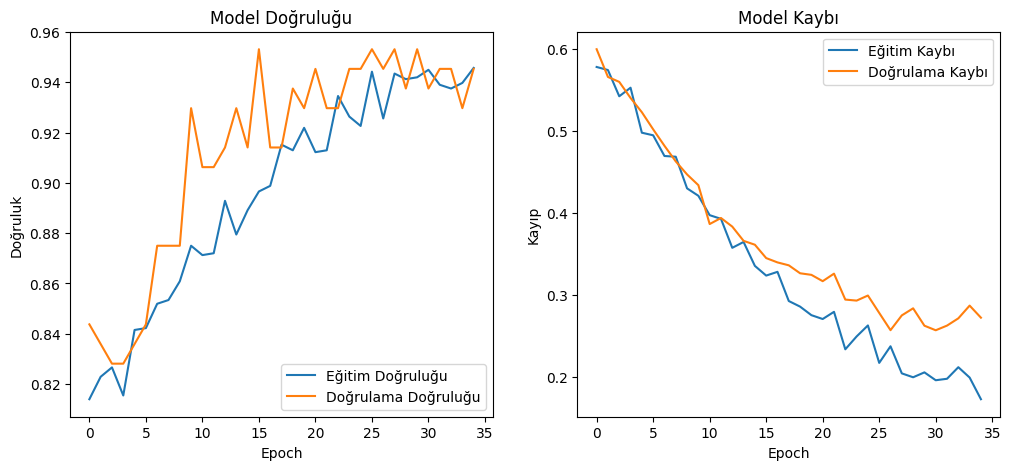

Grafik kaydedildi: /content/drive/MyDrive/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/plots_generated/BodyParts/body_parts_training_plots.jpeg


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.ylabel('Kayıp')
plt.xlabel('Epoch')
plt.legend()

plot_path = os.path.join(PLOT_SAVE_DIR, "BodyParts", "body_parts_training_plots.jpeg")
plt.savefig(plot_path)
plt.show()

print(f"Grafik kaydedildi: {plot_path}")

# Test Görsellerinden Örnek Sonuçlar

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


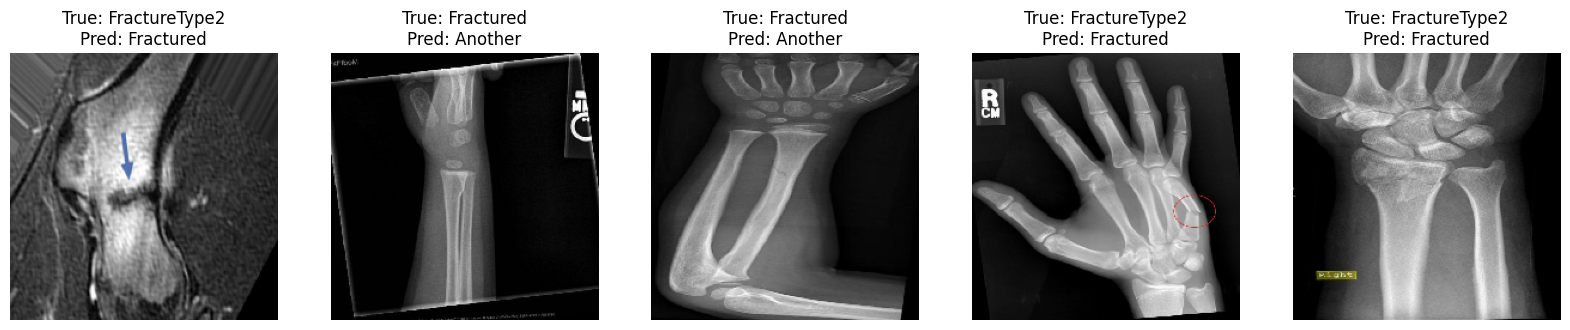

In [ ]:
import random
idxs = random.sample(range(len(test_df)), 5)
fig, axs = plt.subplots(1, 5, figsize=(20,4))
# Get class index to name mapping from the full BODY_PART_CLASS_MAPPING
idx_to_class_name = {i: class_name for class_name, i in test_images.class_indices.items()}
full_idx_to_class_name = {i: class_name for i, class_name in BODY_PART_CLASS_MAPPING.items()}


for i, idx in enumerate(idxs):
    img_path = test_df.iloc[idx]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = np.array(img)  # PIL Image'ı NumPy array'e dönüştür

    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = model.predict(img_preprocessed)
    # Use the full mapping to get the predicted label
    predicted_class_index = np.argmax(pred)
    label_pred = full_idx_to_class_name.get(predicted_class_index, 'Unknown') # Handle potential unknown indices
    label_true = test_df.iloc[idx]['Label']

    axs[i].imshow(img_array)  # NumPy array olarak göster
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


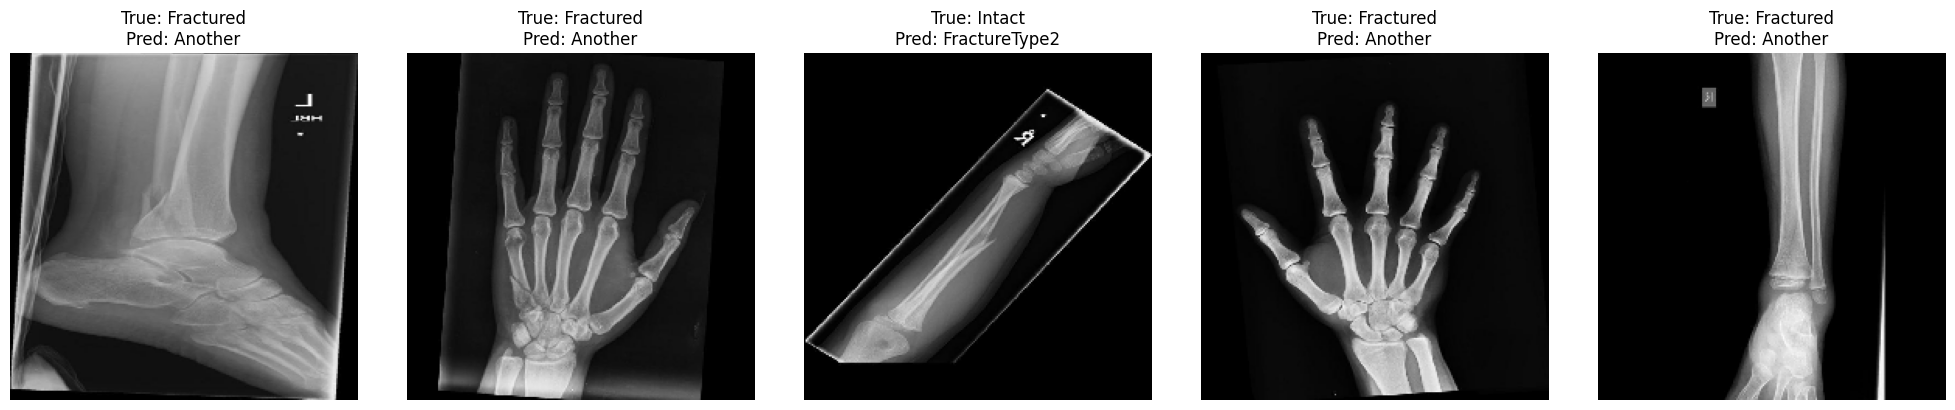

In [ ]:
# Test setinde sadece "Fractured" ve "Intact" örnekleri filtrele
mask = test_df['Label'].isin(['Fractured', 'Intact'])
fracture_test_df = test_df[mask].reset_index(drop=True)

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
# class_labels = list(test_images.class_indices.keys()) # Remove this line

# Get class index to name mapping from the full BODY_PART_CLASS_MAPPING
full_idx_to_class_name = {i: class_name for i, class_name in BODY_PART_CLASS_MAPPING.items()}

for i in range(5):
    img_path = fracture_test_df.iloc[i]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = np.array(img)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = model.predict(img_preprocessed)
    # Use the full mapping to get the predicted label
    predicted_class_index = np.argmax(pred)
    label_pred = full_idx_to_class_name.get(predicted_class_index, 'Unknown') # Handle potential unknown indices
    label_true = fracture_test_df.iloc[i]['Label']

    axs[i].imshow(img_array)
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

## DataFrame’den Sadece "Fractured" ve "Intact" Verilerini Filtrelemesi

In [ ]:
# Sadece Fractured ve Intact etiketli verileri seç
filtered_df = train_df[train_df['Label'].isin(['Fractured', 'Intact'])]
filtered_valid_df = valid_df[valid_df['Label'].isin(['Fractured', 'Intact'])]
filtered_test_df = test_df[test_df['Label'].isin(['Fractured', 'Intact'])]


## Sınıf Mapping’i Sadeleştir

In [ ]:
BINARY_CLASS_MAPPING = {
    0: 'Fractured',
    1: 'Intact'
}


# Yeni DataGenerator’ları Oluştur

In [ ]:
binary_train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)
binary_valid_test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

binary_train_images = binary_train_gen.flow_from_dataframe(
    dataframe=filtered_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=True, seed=42
)
binary_val_images = binary_valid_test_gen.flow_from_dataframe(
    dataframe=filtered_valid_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=False
)
binary_test_images = binary_valid_test_gen.flow_from_dataframe(
    dataframe=filtered_test_df, x_col='Filepath', y_col='Label',
    target_size=(224, 224), color_mode='rgb', class_mode='categorical',
    batch_size=32, shuffle=False
)


Found 345 validated image filenames belonging to 2 classes.
Found 35 validated image filenames belonging to 2 classes.
Found 18 validated image filenames belonging to 2 classes.


## Model Mimarisi (2 Sınıf İçin)

In [ ]:
pretrained_model = tf.keras.applications.resnet50.ResNet50(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet', pooling='avg'
)
pretrained_model.trainable = False  # Dilersen son blokları açabilirsin!

inputs = pretrained_model.input
x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
binary_model = tf.keras.Model(inputs, outputs)

binary_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
binary_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Eğitim ve Değerlendirme

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = binary_model.fit(binary_train_images, validation_data=binary_val_images, epochs=30, callbacks=[early_stop])

# Test değerlendirmesi
preds = binary_model.predict(binary_test_images, verbose=1)
y_true = binary_test_images.classes
y_pred = np.argmax(preds, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=['Fractured', 'Intact']))
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.4905 - loss: 1.2175

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5040 - loss: 1.1919 - val_accuracy: 0.8000 - val_loss: 0.8762
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 467ms/step - accuracy: 0.8379 - loss: 0.6521 - val_accuracy: 0.8000 - val_loss: 0.7771
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step - accuracy: 0.8541 - loss: 0.4116 - val_accuracy: 0.8000 - val_loss: 0.5367
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 433ms/step - accuracy: 0.8165 - loss: 0.4373 - val_accuracy: 0.8000 - val_loss: 0.5449
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 438ms/step - accuracy: 0.8476 - loss: 0.3431 - val_accuracy: 0.8000 - val_loss: 0.5878
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 459ms/step - accuracy: 0.8660 - loss: 0.3086 - val_accuracy: 0.8000 - val_loss: 0.5266
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 461ms/step - accuracy: 0.8628 - loss: 0.3520 - val_accuracy: 0.8286 - val_loss: 0.4872
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 428ms/step - accuracy: 0.9206 - loss: 0.2274 - val_accuracy: 0.8286 - val_lo

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

   Fractured       1.00      1.00      1.00        16
      Intact       1.00      1.00      1.00         2

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

[[16  0]
 [ 0  2]]


## Test Görsellerinden Kırık ve Sağlam Doğru/Tahmin

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


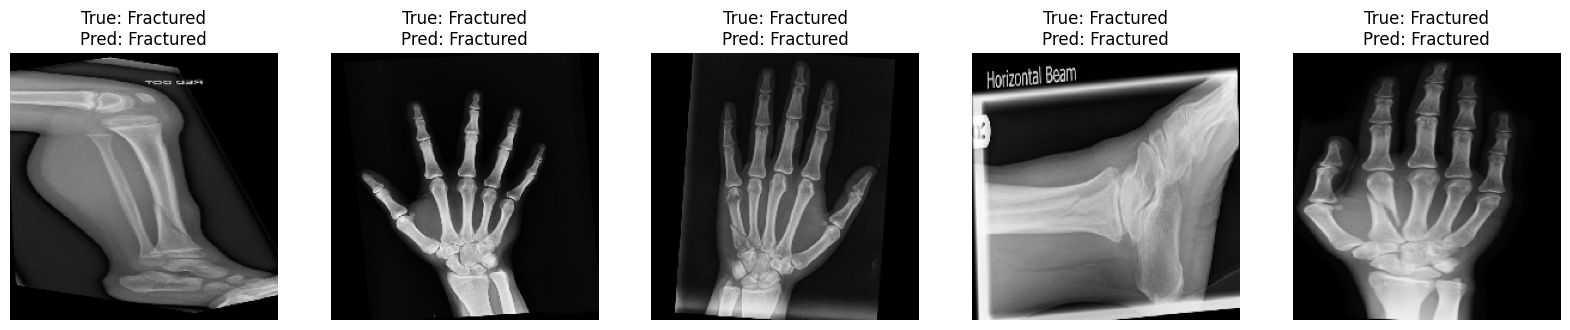

In [ ]:
import random
idxs = random.sample(range(len(filtered_test_df)), 5)
fig, axs = plt.subplots(1, 5, figsize=(20,4))
class_labels = list(binary_test_images.class_indices.keys())

for i, idx in enumerate(idxs):
    img_path = filtered_test_df.iloc[idx]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = np.array(img)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = binary_model.predict(img_preprocessed)
    label_pred = class_labels[np.argmax(pred)]
    label_true = filtered_test_df.iloc[idx]['Label']
    axs[i].imshow(img_array, cmap='gray')
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


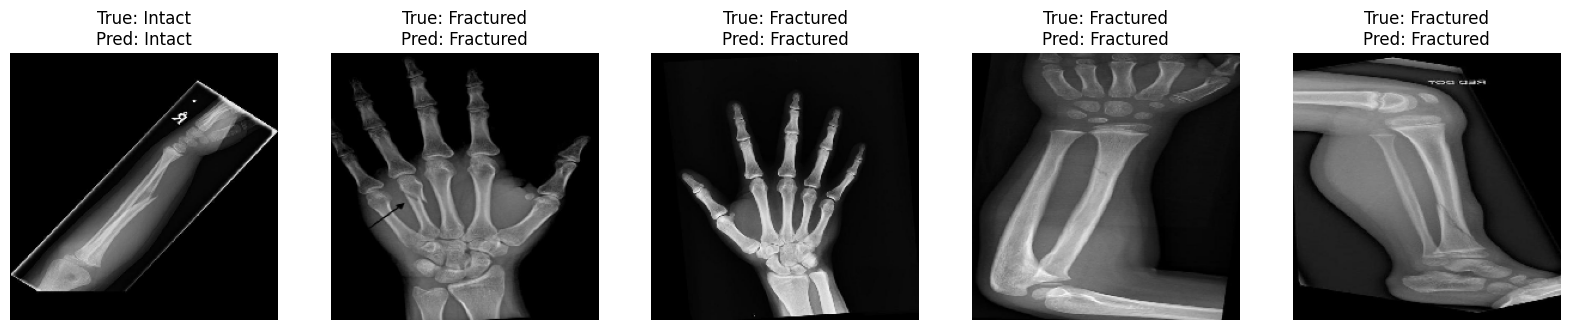

In [ ]:
import random
idxs = random.sample(range(len(filtered_test_df)), 5)
fig, axs = plt.subplots(1, 5, figsize=(20,4))
class_labels = list(binary_test_images.class_indices.keys())

for i, idx in enumerate(idxs):
    img_path = filtered_test_df.iloc[idx]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = np.array(img)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = binary_model.predict(img_preprocessed)
    label_pred = class_labels[np.argmax(pred)]
    label_true = filtered_test_df.iloc[idx]['Label']
    axs[i].imshow(img_array, cmap='gray')
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


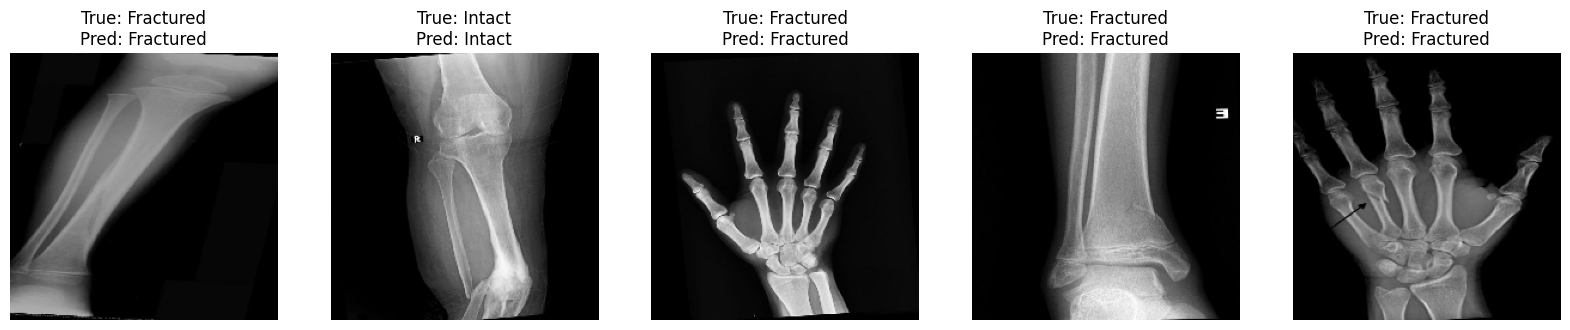

In [ ]:
import random
idxs = random.sample(range(len(filtered_test_df)), 5)
fig, axs = plt.subplots(1, 5, figsize=(20,4))
class_labels = list(binary_test_images.class_indices.keys())

for i, idx in enumerate(idxs):
    img_path = filtered_test_df.iloc[idx]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = np.array(img)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = binary_model.predict(img_preprocessed)
    label_pred = class_labels[np.argmax(pred)]
    label_true = filtered_test_df.iloc[idx]['Label']
    axs[i].imshow(img_array, cmap='gray')
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


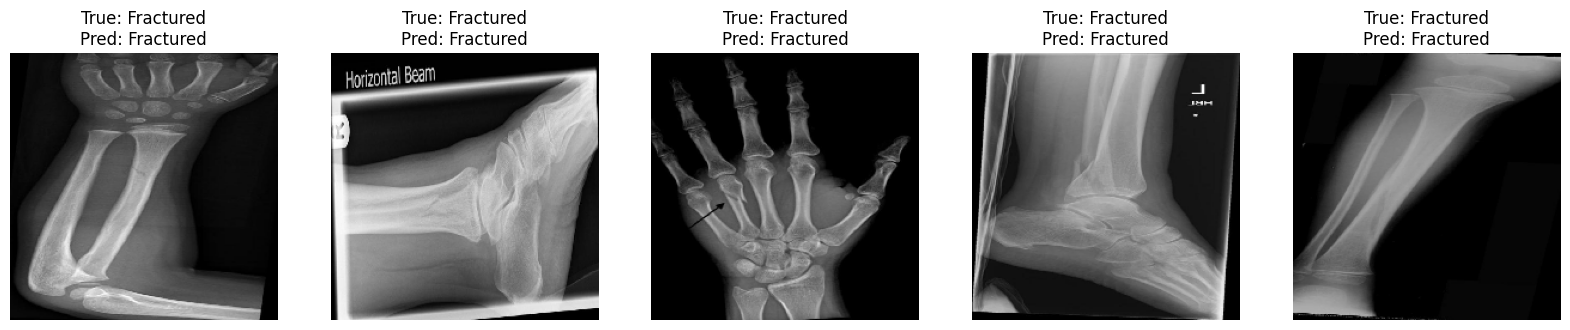

In [ ]:
import random
idxs = random.sample(range(len(filtered_test_df)), 5)
fig, axs = plt.subplots(1, 5, figsize=(20,4))
class_labels = list(binary_test_images.class_indices.keys())

for i, idx in enumerate(idxs):
    img_path = filtered_test_df.iloc[idx]['Filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = np.array(img)
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(img_array, axis=0))
    pred = binary_model.predict(img_preprocessed)
    label_pred = class_labels[np.argmax(pred)]
    label_true = filtered_test_df.iloc[idx]['Label']
    axs[i].imshow(img_array, cmap='gray')
    axs[i].set_title(f'True: {label_true}\nPred: {label_pred}')
    axs[i].axis('off')
plt.show()


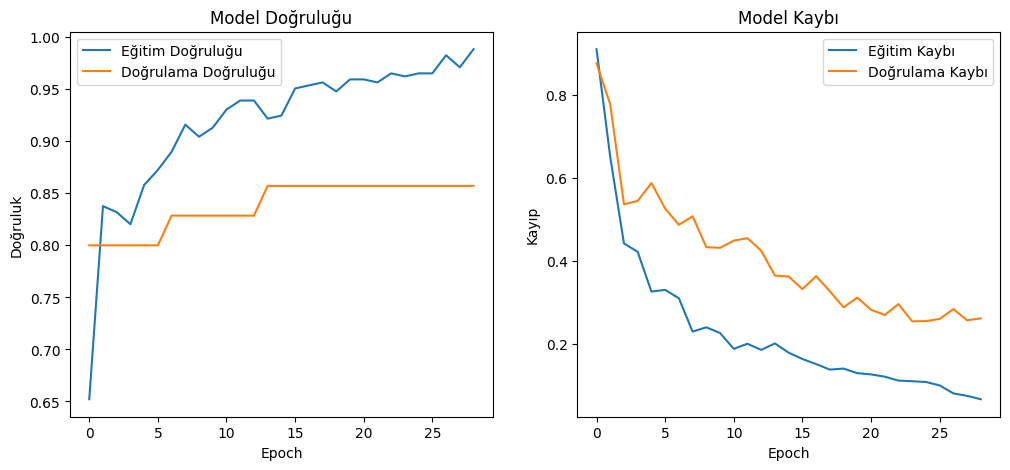

Grafik kaydedildi: /content/drive/MyDrive/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/plots_generated/BodyParts/body_parts_training_plots.jpeg


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.ylabel('Kayıp')
plt.xlabel('Epoch')
plt.legend()

plot_path = os.path.join(PLOT_SAVE_DIR, "BodyParts", "body_parts_training_plots.jpeg")
plt.savefig(plot_path)
plt.show()

print(f"Grafik kaydedildi: {plot_path}")